Biometrich Technologies and Behavioural Security
# **<center>Tutorial - BSIF Facial Expression Recognition</center>**

In [ ]:
#@title Step 1: Load Data and packages
import matplotlib.pyplot as plt
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import os
import dlib
import time
from skimage import feature
from IPython.display import HTML, display
from IPython.display import clear_output

#Function for progress bar.
def progress(value, max=100):
    return HTML("""<progress value='{value}' max='{max}', style='width: 100%'>
            {value}
        </progress>""".format(value=value, max=max))

from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

#downloaded = drive.CreateFile({'id': '1nWbItUzADjC3OtN3ijph6S5PIMTYfT2H'})   # replace the id with id of file you want to access
downloaded = drive.CreateFile({'id': '1pq7wiPImgPMaCszC5dvdLx5tq-cUoe_W'})
downloaded.GetContentFile('jaffedbase.zip')        # replace the file name with your file
!unzip jaffedbase
clear_output()
print('Done! Press the Refresh button if files are not visible.')

Done! Press the Refresh button if files are not visible.


In [ ]:
#BSIF Filters download code
downloaded = drive.CreateFile({'id': '1CPk07Oqn5gmKn8yXaEns-0yZc5ZAs3Su'})   # replace the id with id of file you want to access
downloaded.GetContentFile('texturefilters.zip')        # replace the file name with your file
!unzip texturefilters
print('Done! Press the Refresh button if files are not visible.')

Archive:  texturefilters.zip
   creating: texturefilters/
  inflating: texturefilters/.DS_Store  
   creating: __MACOSX/texturefilters/
  inflating: __MACOSX/texturefilters/._.DS_Store  
  inflating: texturefilters/ICAtextureFilters_11x11_10bit.mat  
  inflating: __MACOSX/texturefilters/._ICAtextureFilters_11x11_10bit.mat  
  inflating: texturefilters/ICAtextureFilters_11x11_11bit.mat  
  inflating: __MACOSX/texturefilters/._ICAtextureFilters_11x11_11bit.mat  
  inflating: texturefilters/ICAtextureFilters_11x11_12bit.mat  
  inflating: __MACOSX/texturefilters/._ICAtextureFilters_11x11_12bit.mat  
  inflating: texturefilters/ICAtextureFilters_11x11_5bit.mat  
  inflating: __MACOSX/texturefilters/._ICAtextureFilters_11x11_5bit.mat  
  inflating: texturefilters/ICAtextureFilters_11x11_6bit.mat  
  inflating: __MACOSX/texturefilters/._ICAtextureFilters_11x11_6bit.mat  
  inflating: texturefilters/ICAtextureFilters_11x11_7bit.mat  
  inflating: __MACOSX/texturefilters/._ICAtextureFilters_11

In [ ]:
#@title Step 2:  Create data and label structures
path = "/content/jaffedbase/"
images = os.listdir(path)

print('Extracting faces...')
out = display(progress(0, len(images)*2), display_id=True)
kk=0
t = time.time()
data = []
labels = []


for j in images:
    if 'tiff' in j:
      img = cv2.imread(path+"/"+j)
      data.append(img)
      if 'HA' in j:
        labels.append(0)
      elif 'AN' in j:
        labels.append(1)
      elif 'SA' in j:
        labels.append(2)
      elif 'DI' in j:
        labels.append(3)
      elif 'FE' in j:
        labels.append(4)
      elif 'SU' in j:
        labels.append(5)
      elif 'NE' in j:
        labels.append(6)
    kk=kk+1
    out.update(progress(kk, len(images)))

elapsed = 'Process completed! Elapsed time: %.2f s' %(time.time() - t)
print(elapsed)

Extracting faces...


Process completed! Elapsed time: 0.56 s


In [ ]:
emotion_labels = ["Happy","Angry","Sad", "Disgust", "Fear", "Surprise", "Neutral"]
num_classes = len(emotion_labels)


In [ ]:
X = np.array(data)
Y = np.array(labels)

Happy


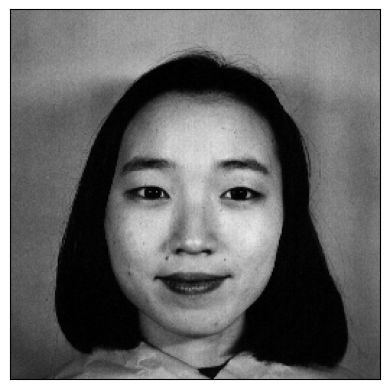

In [ ]:
#@title Choose a sample to visualize
sample_number = 3 #@param {type:"slider", min:0, max:100, step:1}

import numpy as np


img = data[sample_number]
fig=plt.imshow(img,cmap='gray')
fig.axes.get_xaxis().set_visible(False)
fig.axes.get_yaxis().set_visible(False)
print(emotion_labels[Y[sample_number]])


In [ ]:
def bsif(img, filterpath):
    f = scipy.io.loadmat(filterpath)
    texturefilters = f.get('ICAtextureFilters')

    # Initialize
    img = img.astype("float");
    numScl = np.shape(texturefilters)[2]
    codeImg = np.ones(np.shape(img))

    # Make spatial coordinates for sliding window
    r = int(math.floor(np.shape(texturefilters)[0] / 2))

    # Wrap image (increase image size according to maximum filter radius by wrapping around)
    upimg = img[0:r, :]
    btimg = img[-r:, :]
    lfimg = img[:, 0:r]
    rtimg = img[:, -r:]
    cr11 = img[0:r, 0:r]
    cr12 = img[0:r, -r:]
    cr21 = img[-r:, 0:r]
    cr22 = img[-r:, -r:]
    imgWrap = np.vstack(
        (np.hstack((cr22, btimg, cr21)), np.hstack((rtimg, img, lfimg)), np.hstack((cr12, upimg, cr11))))

    # Loop over scales
    for i in range(numScl):
        tmp = texturefilters[:, :, numScl - i - 1]
        ci = signal.convolve2d(imgWrap, np.rot90(tmp, 2), mode='valid')
        t = np.multiply(np.double(ci > 0), 2 ** i)
        codeImg = codeImg + t

    hist_bsif = np.histogram(codeImg.ravel(), bins=np.arange(1,(2**numScl)+2))
    hist_bsif = hist_bsif[0]

    # normalize the histogram
    hist_bsif = hist_bsif/(hist_bsif.sum() + 1e-7)


    return codeImg, hist_bsif

In [ ]:
file_path = "/content/texturefilters/ICAtextureFilters_9x9_8bit.mat"

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import cv2
from scipy import signal
import scipy.io
import math
data = []

for i in X:
  gray = cv2.cvtColor(i, cv2.COLOR_BGR2GRAY)
  img_bsif,hist = bsif(gray,file_path)
  data.append(hist)
data = np.array(data)

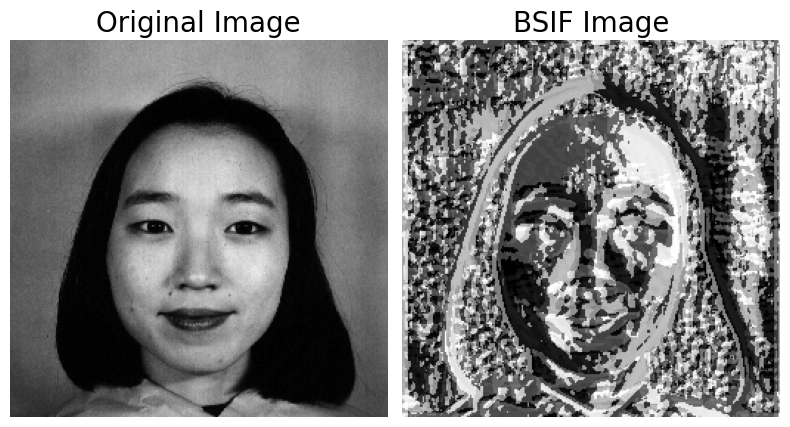

In [ ]:
from scipy import io, signal
import math


gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_bsif,hist = bsif(gray,file_path)

#show images
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 8), sharex=True, sharey=True)
plt.subplots_adjust(0.15)
axes[0].imshow(img, cmap="gray")
axes[0].axis('off')
axes[0].set_title('Original Image', fontsize=20)
axes[1].imshow(img_bsif,cmap="gray")
axes[1].axis('off')
axes[1].set_title('BSIF Image', fontsize=20)
fig.tight_layout()
plt.show()

In [ ]:
#@title Step 3: Split and normalize train e test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(data,Y,test_size = 0.1)

#train and test norm
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
x_train = (x_train - 0.5) * 2
x_test = (x_test - 0.5) * 2

print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')


x_train shape: (191, 256)
191 train samples
22 test samples


In [ ]:
#@title Step 4: Fit a KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier(n_neighbors=1)
neigh.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [ ]:
#@title Step 5: Performance Evaluation

from sklearn.metrics import accuracy_score
y_pred = neigh.predict(x_test)
acc='Total Accuracy: %.2f %%' % (accuracy_score(y_test, y_pred)*100)
print(acc)

Total Accuracy: 72.73 %


[Text(0.5, 68.24999999999999, 'Predicted label'),
 Text(83.24999999999999, 0.5, 'True label')]

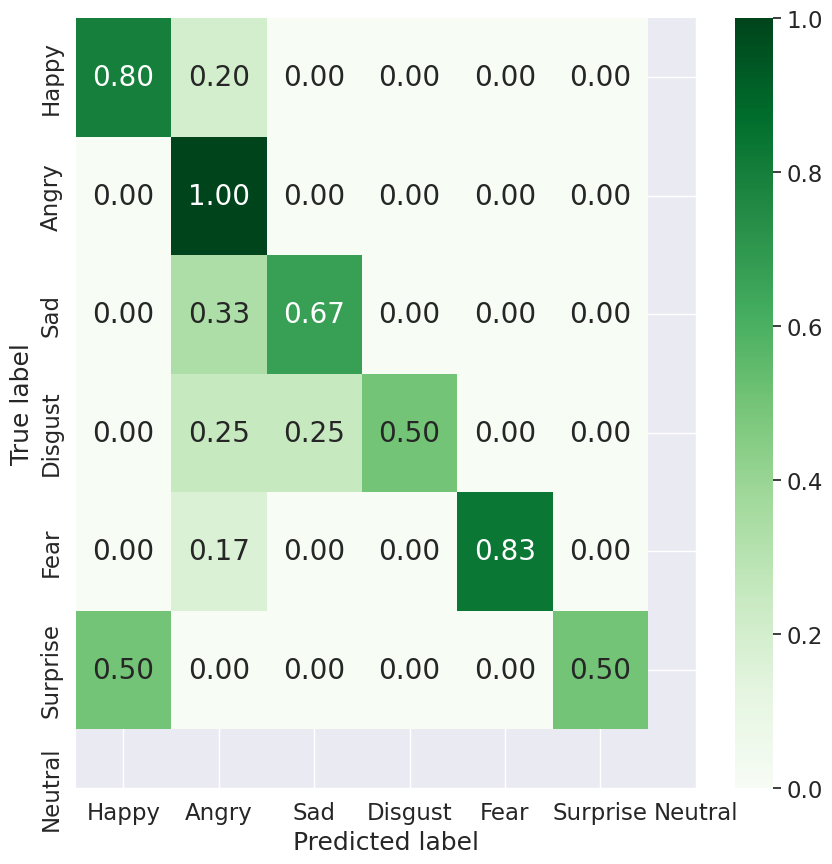

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
cm_normalised = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.set(font_scale=1.5)
fig, ax = plt.subplots(figsize=(10,10))
ax = sns.heatmap(cm_normalised, annot=True, linewidths=0, square=False,
                    cmap="Greens", yticklabels=emotion_labels, xticklabels=emotion_labels, vmin=0, vmax=np.max(cm_normalised),
                    fmt=".2f", annot_kws={"size": 20})
ax.set(xlabel='Predicted label', ylabel='True label')